# Synthetic scatterplot data generation

This notebook implements the generation and labeling workflow from `scatterplot_workflow-no metrics.md`. The full design has 21,640 cases and 2,164,000 scatterplots at `R=100`, so data materialization is explicit instead of automatic.

In [29]:
from pathlib import Path
import os
import pandas as pd

PROJECT_DIR = Path.cwd()
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_DIR / ".matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

from synthetic_scatterplot_generator import (
    SNR_LEVELS,
    build_case_table,
    build_function_specs,
    export_case_metadata,
    generate_case_data,
    write_case_npz,
    write_dataset_cases,
)


## 1. Build the function library and case table

In [30]:
specs = build_function_specs()
case_table = build_case_table(specs)

print(f"function configs: {len(specs):,}")
print(f"SNR levels: {len(SNR_LEVELS):,}")
print(f"cases: {len(case_table):,}")
print(case_table.groupby("experiment").size())
case_table.head()


function configs: 420
SNR levels: 50
cases: 21,640
experiment
heteroscedasticity      240
main                  21000
sampling                400
dtype: int64


,case_index,case_id,base_seed,experiment,function_type,function_name,config_index,function_formula,shape_params,snr,...,tp_pattern,tp_trend,s_curve,threshold,strength,high_spread,high_spread_ratio,changing_spread,density,clusters
0,1,main_F00_cfg01_snr0p05_constant_uniform,1000,main,F00,Random,1,f(x) = constant,"{""constant"": 0.05, ""null_variance_reference"": ...",0.05,...,None,None,False,False,Very Weak,True,4.472136,False,Even,False
1,2,main_F00_cfg01_snr0p08_constant_uniform,2000,main,F00,Random,1,f(x) = constant,"{""constant"": 0.05, ""null_variance_reference"": ...",0.08,...,None,None,False,False,Very Weak,True,3.535534,False,Even,False
2,3,main_F00_cfg01_snr0p1_constant_uniform,3000,main,F00,Random,1,f(x) = constant,"{""constant"": 0.05, ""null_variance_reference"": ...",0.10,...,None,None,False,False,Very Weak,True,3.162278,False,Even,False
3,4,main_F00_cfg01_snr0p13_constant_uniform,4000,main,F00,Random,1,f(x) = constant,"{""constant"": 0.05, ""null_variance_reference"": ...",0.13,...,None,None,False,False,Very Weak,True,2.773501,False,Even,False
4,5,main_F00_cfg01_snr0p17_constant_uniform,5000,main,F00,Random,1,f(x) = constant,"{""constant"": 0.05, ""null_variance_reference"": ...",0.17,...,None,None,False,False,Very Weak,True,2.425356,False,Even,False


In [31]:
assert len(specs) == 420
assert len(SNR_LEVELS) == 50
assert len(case_table) == 21_640
assert case_table["case_id"].is_unique
assert case_table.groupby("experiment").size().to_dict() == {
    "heteroscedasticity": 240,
    "main": 21_000,
    "sampling": 400,
}
assert (case_table.groupby("function_type")["config_index"].nunique() == 20).all()

case_table.groupby("function_type")["config_index"].nunique().to_frame("n_configs")


,n_configs
function_type,
F00,20
F01,20
F02,20
F03,20
F04,20
F05,20
F06,20
F07,20
F08,20


## 2. Export case metadata and ground-truth labels

In [32]:
OUTPUT_DIR = PROJECT_DIR / "synthetic_scatterplot_output"
metadata_paths = export_case_metadata(case_table, OUTPUT_DIR)
metadata_paths


{'csv': PosixPath('/Users/mimi/Documents/Code/Github/GSA-work/explore/no0/form_260617/synthetic_scatterplot_output/case_metadata.csv'),
 'jsonl': PosixPath('/Users/mimi/Documents/Code/Github/GSA-work/explore/no0/form_260617/synthetic_scatterplot_output/case_metadata.jsonl')}

## 3. Generate and inspect one case

`generate_case_data` returns a nested object with `case_metadata`, `ground_truth_labels`, and `data`. The `realizations` array has shape `(R, n, 2)`, where the last dimension is `(x, y)`. `f_x_clean` and `sigma_x` have shape `(R, n)`.

In [33]:
demo_case = case_table.query(
    "function_type == 'F04' and config_index == 13 and snr_label == '5' and experiment == 'main'"
).iloc[0]

demo = generate_case_data(demo_case, specs, R=3, n=500)
print(demo_case["case_id"])
print(demo["ground_truth_labels"])
print(demo["data"]["realizations"].shape)
print(demo["data"]["f_x_clean"].shape)


main_F04_cfg13_snr5_constant_uniform
{'direction': 'Positive', 'monotonicity': 'Monotonic', 'linearity': 'Nonlinear', 'convexity': 'Concave', 'saturation': 'Strong', 'late_slope_early_slope_ratio': 0.00012310249689206665, 'tp_count': 0, 'tp_types': None, 'tp_pattern': None, 'tp_trend': None, 's_curve': False, 'threshold': False, 'strength': 'Medium', 'high_spread': False, 'changing_spread': False, 'density': 'Even', 'clusters': False}
(3, 500, 2)
(3, 500)


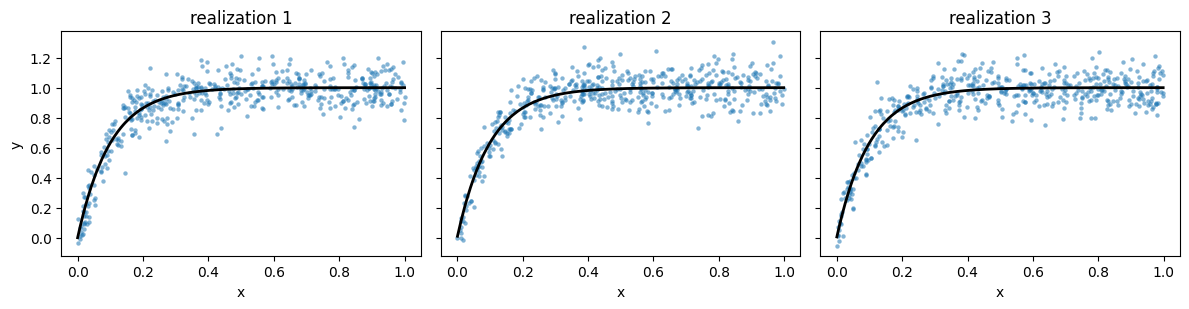

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharex=True, sharey=True)
for i, ax in enumerate(axes):
    points = demo["data"]["realizations"][i]
    ax.scatter(points[:, 0], points[:, 1], s=10, alpha=0.55, linewidths=0)
    order = points[:, 0].argsort()
    ax.plot(points[order, 0], demo["data"]["f_x_clean"][i][order], color="black", linewidth=2)
    ax.set_title(f"realization {i + 1}")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
fig.tight_layout()
plt.show()


## 4. Plot one scatterplot for each base function family

This uses one representative main-experiment case from each of the 21 function families.

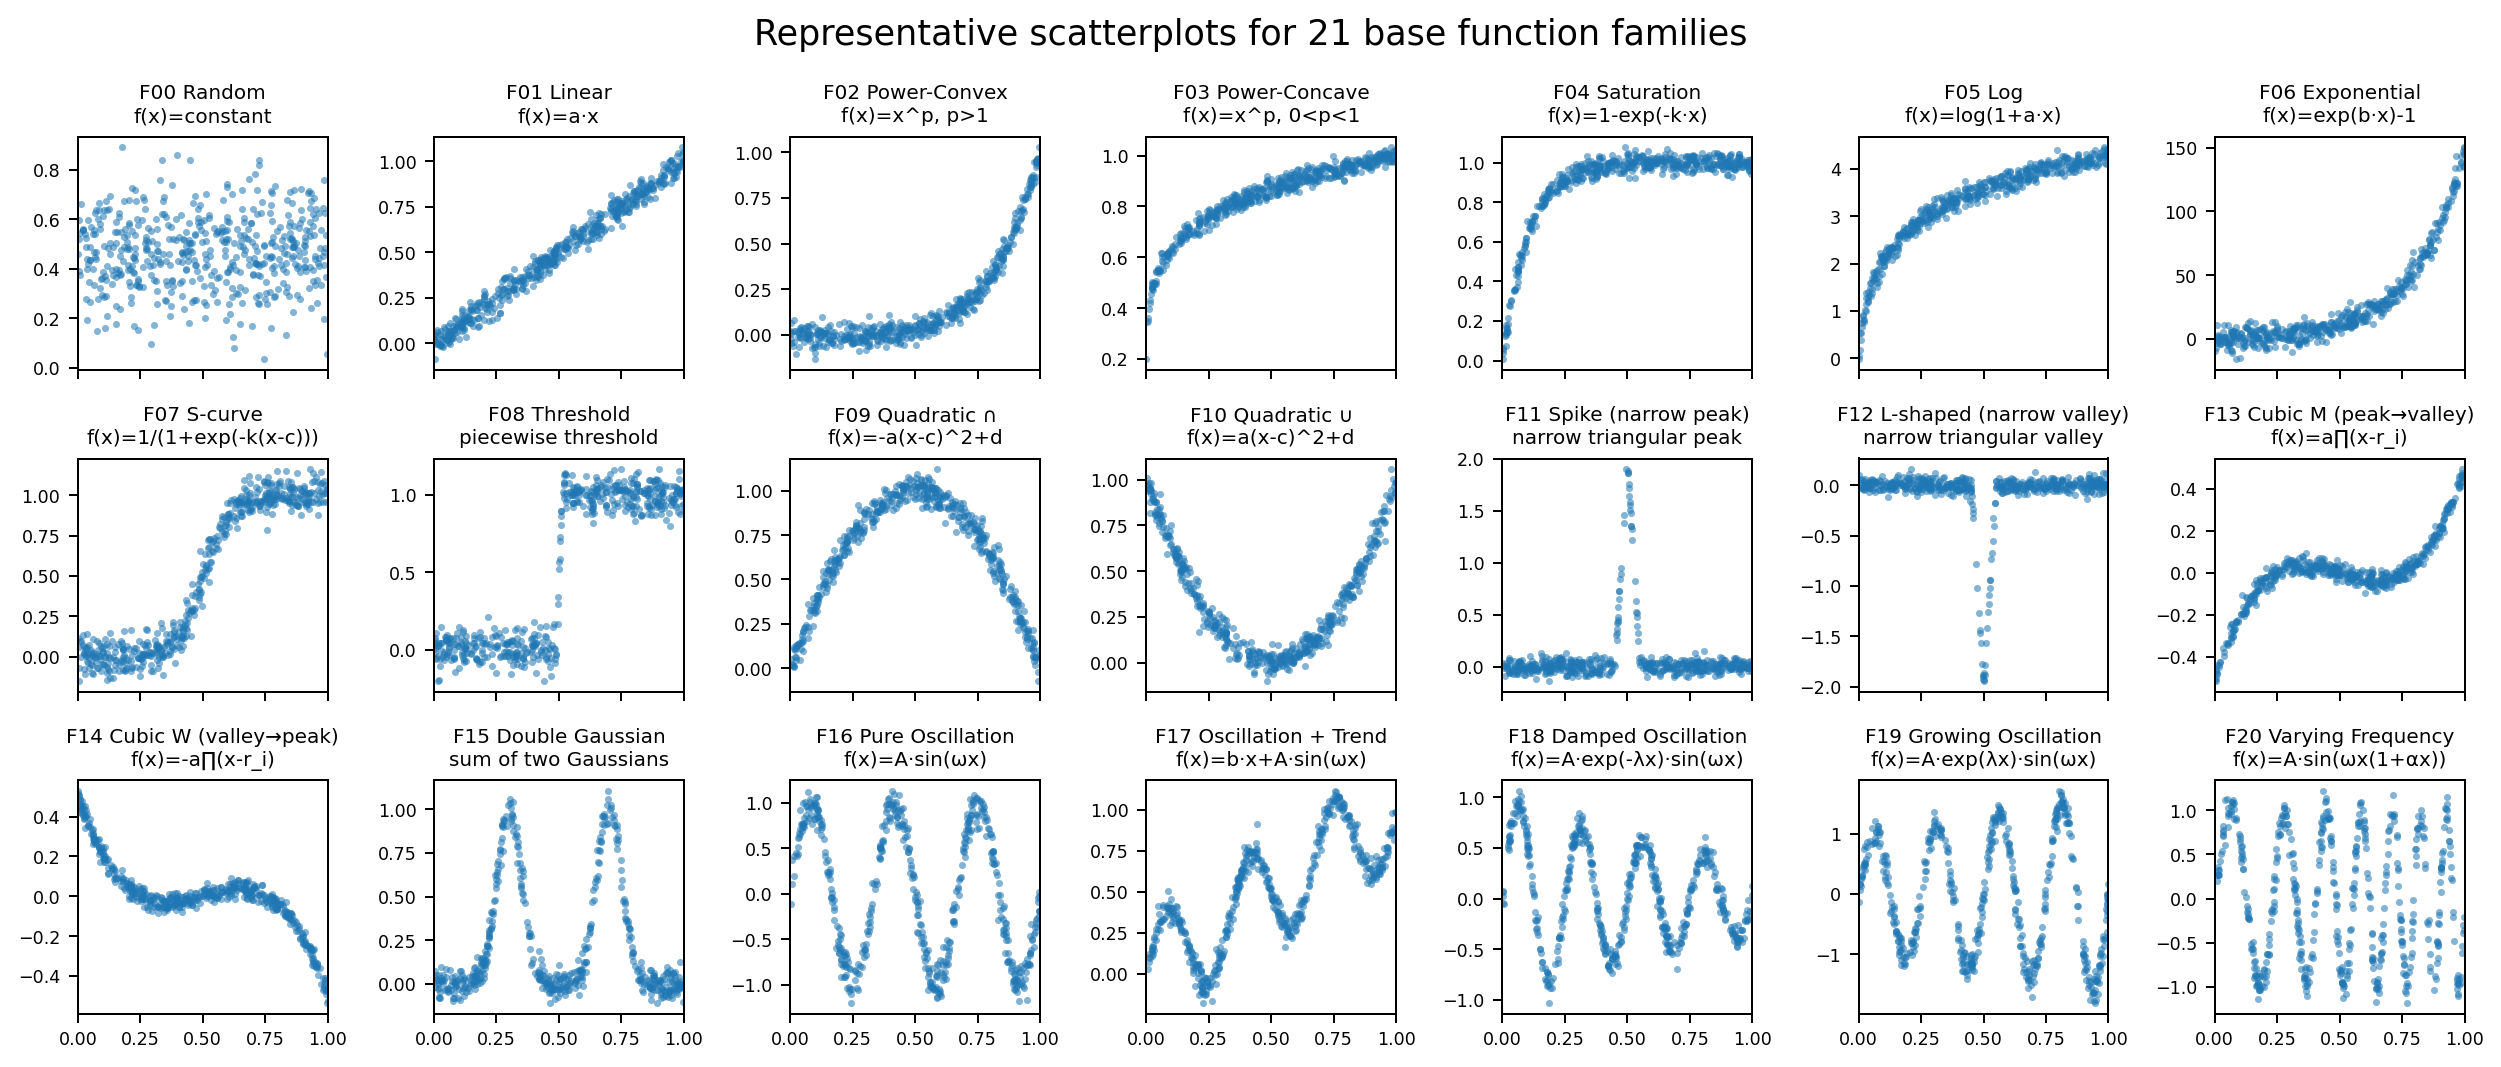

In [40]:
representative_families = [
    ("F00", 10, "F00 Random"),
    ("F01", 11, "F01 Linear"),
    ("F02", 13, "F02 Power-Convex"),
    ("F03", 13, "F03 Power-Concave"),
    ("F04", 13, "F04 Saturation"),
    ("F05", 13, "F05 Log"),
    ("F06", 13, "F06 Exponential"),
    ("F07", 12, "F07 S-curve"),
    ("F08", 7, "F08 Threshold"),
    ("F09", 13, "F09 Quadratic ∩"),
    ("F10", 13, "F10 Quadratic ∪"),
    ("F11", 15, "F11 Spike (narrow peak)"),
    ("F12", 15, "F12 L-shaped (narrow valley)"),
    ("F13", 5, "F13 Cubic M (peak→valley)"),
    ("F14", 5, "F14 Cubic W (valley→peak)"),
    ("F15", 13, "F15 Double Gaussian"),
    ("F16", 10, "F16 Pure Oscillation"),
    ("F17", 12, "F17 Oscillation + Trend"),
    ("F18", 10, "F18 Damped Oscillation"),
    ("F19", 10, "F19 Growing Oscillation"),
    ("F20", 10, "F20 Varying Frequency"),
]

formula_labels = {
    "F00": "f(x)=constant",
    "F01": "f(x)=a·x",
    "F02": "f(x)=x^p, p>1",
    "F03": "f(x)=x^p, 0<p<1",
    "F04": "f(x)=1-exp(-k·x)",
    "F05": "f(x)=log(1+a·x)",
    "F06": "f(x)=exp(b·x)-1",
    "F07": "f(x)=1/(1+exp(-k(x-c)))",
    "F08": "piecewise threshold",
    "F09": "f(x)=-a(x-c)^2+d",
    "F10": "f(x)=a(x-c)^2+d",
    "F11": "narrow triangular peak",
    "F12": "narrow triangular valley",
    "F13": "f(x)=a∏(x-r_i)",
    "F14": "f(x)=-a∏(x-r_i)",
    "F15": "sum of two Gaussians",
    "F16": "f(x)=A·sin(ωx)",
    "F17": "f(x)=b·x+A·sin(ωx)",
    "F18": "f(x)=A·exp(-λx)·sin(ωx)",
    "F19": "f(x)=A·exp(λx)·sin(ωx)",
    "F20": "f(x)=A·sin(ωx(1+αx))",
}

family_rows = []
for function_type, config_index, display_name in representative_families:
    row = case_table.query(
        "experiment == 'main' and function_type == @function_type and "
        "config_index == @config_index and snr_label == '50'"
    ).iloc[0].copy()
    row["display_name"] = display_name
    family_rows.append(row)

family_cases = pd.DataFrame(family_rows).reset_index(drop=True)
assert family_cases["function_type"].tolist() == [item[0] for item in representative_families]

fig, axes = plt.subplots(3, 7, figsize=(14, 6), sharex=True, dpi=180)
axes = axes.ravel()

for ax, (_, case) in zip(axes, family_cases.iterrows()):
    generated = generate_case_data(case, specs, R=1, n=500)
    points = generated["data"]["realizations"][0]
    ax.scatter(points[:, 0], points[:, 1], s=8, alpha=0.55, linewidths=0)
    ax.set_title(
        f"{case['display_name']}\n{formula_labels[case['function_type']]}",
        fontsize=8,
        linespacing=1.25,
    )
    ax.set_xlim(0, 1)
    ax.tick_params(labelsize=7)

fig.suptitle("Representative scatterplots for 21 base function families", fontsize=14)
fig.tight_layout()
plt.show()


## 5. Write generated scatterplots

The full dataset is large. Use `write_case_npz` for selected cases, or filter `case_table` before calling `write_dataset_cases`.

In [36]:
DEMO_DATA_DIR = OUTPUT_DIR / "demo_npz"
demo_npz_path = write_case_npz(demo_case, DEMO_DATA_DIR, specs, R=3, n=500)
demo_npz_path


PosixPath('/Users/mimi/Documents/Code/Github/GSA-work/explore/no0/form_260617/synthetic_scatterplot_output/demo_npz/main_F04_cfg13_snr5_constant_uniform.npz')

In [37]:
RUN_FULL_EXPORT = False
FULL_DATA_DIR = OUTPUT_DIR / "npz_cases"

if RUN_FULL_EXPORT:
    paths = write_dataset_cases(case_table, FULL_DATA_DIR, specs)
    print(f"wrote {len(paths):,} case files to {FULL_DATA_DIR}")
else:
    print("Full export is disabled. Set RUN_FULL_EXPORT = True after confirming disk budget.")


Full export is disabled. Set RUN_FULL_EXPORT = True after confirming disk budget.
